In [ ]:
import pandas as pd

#importing z score dataframes

df_SL = pd.read_csv('z_score_df_SL_over_US_071626.csv').set_index('peptide')

df_hbdb = pd.read_csv('z_hbdb_loo_results_071626.csv').set_index('peptide')

#importing RPK dataframes

df_SL_rpk = pd.read_csv('./preprocessing/earliest_tp_rpk_avg_value_for_cohort_techreps_071626.csv').set_index('peptide')

df_hbdb_rpk = pd.read_csv('./preprocessing/hbdb_pass_100k_techreps_averaged_071626.csv').set_index('peptide')

peps_metadata = pd.read_csv('lassa_library_sequences_species_standardized_070726.csv').set_index('seq_id')

peps_keep = pd.read_csv('peps_passing_z_score_5_in_10_or_more_SL_971826.csv').set_index('peptide')

In [67]:
df_plot_rpk = pd.concat([df_SL_rpk, df_hbdb_rpk], axis=1)

#only keep filtered peptides from peps_metadata
peps_metadata = peps_metadata.loc[peps_keep.index]

df_plot_rpk_peps = df_plot_rpk.loc[peps_metadata.index]

In [69]:
#Long format for merging with metadata
exposed_rpk_long = (
    df_plot_rpk_peps.reset_index()
    .melt(id_vars="peptide", var_name="sample_id", value_name="RPK")
    .merge(
        peps_metadata[[
            "sequence", "family", "genus", "species", "accession", "protein_name"
        ]],
        on="peptide",
        how="left"
    )
).set_index('peptide')

In [70]:
#select genus of interest
orthoebolavirus = peps_metadata[peps_metadata['genus'] == 'Orthoebolavirus'] 

# subset to species of interest
orthoebolavirus_zairense = orthoebolavirus[orthoebolavirus['species'] == 'Orthoebolavirus zairense']

#look at unique protein_names
orthoebolavirus_zairense['protein_name'].unique()

#standardize protein_names
glycoprotein_valid = ['envelope_glycoprotein', 'virion spike glycoprotein precursor']
nucleoprotein_valid = ['nucleoprotein']
matrix_protein_valid = ['matrix protein']

#subset peptide metadata to proteins of interest
glycoprotein_peps = orthoebolavirus_zairense[orthoebolavirus_zairense['protein_name'].isin(glycoprotein_valid)]
nucleoprotein_peps = orthoebolavirus_zairense[orthoebolavirus_zairense['protein_name'].isin(nucleoprotein_valid)]

In [96]:
import numpy as np
df_plot_rpk_ebov_gp = df_plot_rpk.loc[glycoprotein_peps.index].reset_index()

df_plot_rpk_ebov_gp_long = pd.melt(df_plot_rpk_ebov_gp, id_vars=['peptide'], var_name='sample_id', value_name='RPK')

df_plot_rpk_ebov_gp_long['category'] = np.where(df_plot_rpk_ebov_gp_long['sample_id'].str.startswith('HBDB'), 'US', 'SL')

df_plot_rpk_ebov_gp_long['log2(rpk+1)'] = np.log2(df_plot_rpk_ebov_gp_long['RPK'] + 1)


In [99]:
df_plot_rpk_ebov_gp_long['peptide'].to_list()

['WGV39868.1|precursor|Zaire_ebolavirus|isolate=COY1925|Homo_sapiens|Guinea:_Conakry|10-Nov-2014|segment=?|strain=?|tile_3',
 'WGV39868.1|precursor|Zaire_ebolavirus|isolate=COY1925|Homo_sapiens|Guinea:_Conakry|10-Nov-2014|segment=?|strain=?|tile_12',
 'WGV39868.1|precursor|Zaire_ebolavirus|isolate=COY1925|Homo_sapiens|Guinea:_Conakry|10-Nov-2014|segment=?|strain=?|tile_13',
 'WGV39868.1|precursor|Zaire_ebolavirus|isolate=COY1925|Homo_sapiens|Guinea:_Conakry|10-Nov-2014|segment=?|strain=?|tile_14',
 'WGV39868.1|precursor|Zaire_ebolavirus|isolate=COY1925|Homo_sapiens|Guinea:_Conakry|10-Nov-2014|segment=?|strain=?|tile_16',
 'WGV39868.1|precursor|Zaire_ebolavirus|isolate=COY1925|Homo_sapiens|Guinea:_Conakry|10-Nov-2014|segment=?|strain=?|tile_3',
 'WGV39868.1|precursor|Zaire_ebolavirus|isolate=COY1925|Homo_sapiens|Guinea:_Conakry|10-Nov-2014|segment=?|strain=?|tile_12',
 'WGV39868.1|precursor|Zaire_ebolavirus|isolate=COY1925|Homo_sapiens|Guinea:_Conakry|10-Nov-2014|segment=?|strain=?|tile

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'tile_3'),
  Text(1, 0, 'tile_12'),
  Text(2, 0, 'tile_13'),
  Text(3, 0, 'tile_14'),
  Text(4, 0, 'tile_16')])

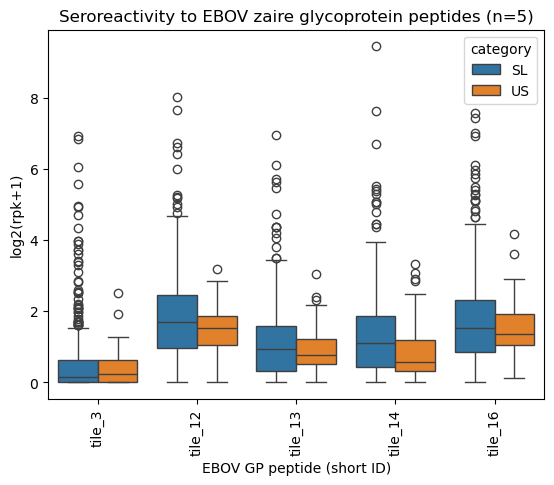

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

ax = sns.boxplot(data=df_plot_rpk_ebov_gp_long, x='peptide', y='log2(rpk+1)', hue='category')

xticks = ax.get_xticks()
orig_labels = [t.get_text() for t in ax.get_xticklabels()]

short_labels = [lab.split('|')[-1][:10] for lab in orig_labels]  # last field, first 10 chars

ax.set_xticks(xticks, short_labels)  # matplotlib ≥3.5 allows labels argument[web:71][web:75]
ax.set_xlabel("EBOV GP peptide (short ID)")
ax.set_title('Seroreactivity to EBOV zaire glycoprotein peptides (n=5)')
plt.xticks(rotation=90)

In [102]:
import numpy as np
df_plot_rpk_ebov_gp = df_plot_rpk.loc[nucleoprotein_peps.index].reset_index()

df_plot_rpk_ebov_gp_long = pd.melt(df_plot_rpk_ebov_gp, id_vars=['peptide'], var_name='sample_id', value_name='RPK')

df_plot_rpk_ebov_gp_long['category'] = np.where(df_plot_rpk_ebov_gp_long['sample_id'].str.startswith('HBDB'), 'US', 'SL')

df_plot_rpk_ebov_gp_long['log2(rpk+1)'] = np.log2(df_plot_rpk_ebov_gp_long['RPK'] + 1)


Text(0.5, 1.0, 'Seroreactivity to EBOV zaire nucleoprotein peptides (n=8)')

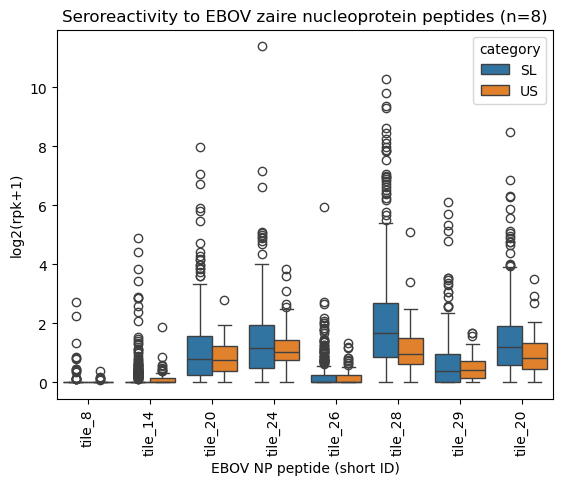

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

ax = sns.boxplot(data=df_plot_rpk_ebov_gp_long, x='peptide', y='log2(rpk+1)', hue='category')

xticks = ax.get_xticks()
orig_labels = [t.get_text() for t in ax.get_xticklabels()]

short_labels = [lab.split('|')[-1][:10] for lab in orig_labels]  # last field, first 10 chars

ax.set_xticks(xticks, short_labels)  # matplotlib ≥3.5 allows labels argument[web:71][web:75]
ax.set_xlabel("EBOV NP peptide (short ID)")
ax.set_title('Seroreactivity to EBOV zaire glycoprotein peptides (n=5)')
plt.xticks(rotation=90)

ax.set_title('Seroreactivity to EBOV zaire nucleoprotein peptides (n=8)')

## map onto protein

In [64]:
#for the nucleoprotein

# NP_066243.1 nucleoprotein [Zaire ebolavirus]
ebov_zaire_nucleoprotein_refseq = """
>NP_066243.1 nucleoprotein [Zaire ebolavirus]
MDSRPQKIWMAPSLTESDMDYHKILTAGLSVQQGIVRQRVIPVYQVNNLEEICQLIIQAFEAGVDFQESA
DSFLLMLCLHHAYQGDYKLFLESGAVKYLEGHGFRFEVKKRDGVKRLEELLPAVSSGKNIKRTLAAMPEE
ETTEANAGQFLSFASLFLPKLVVGEKACLEKVQRQIQVHAEQGLIQYPTAWQSVGHMMVIFRLMRTNFLI
KFLLIHQGMHMVAGHDANDAVISNSVAQARFSGLLIVKTVLDHILQKTERGVRLHPLARTAKVKNEVNSF
KAALSSLAKHGEYAPFARLLNLSGVNNLEHGLFPQLSAIALGVATAHGSTLAGVNVGEQYQQLREAATEA
EKQLQQYAESRELDHLGLDDQEKKILMNFHQKKNEISFQQTNAMVTLRKERLAKLTEAITAASLPKTSGH
YDDDDDIPFPGPINDDDNPGHQDDDPTDSQDTTIPDVVVDPDDGSYGEYQSYSENGMNAPDDLVLFDLDE
DDEDTKPVPNRSTKGGQQKNSQKGQHIEGRQTQSRPIQNVPGPHRTIHHASAPLTDNDRRNEPSGSTSPR
MLTPINEEADPLDDADDETSSLPPLESDDEEQDRDGTSNRTPTVAPPAPVYRDHSEKKELPQDEQQDQDH
TQEARNQDSDNTQSEHSFEEMYRHILRSQGPFDAVLYYHMMKDEPVVFSTSDGKEYTYPDSLEEEYPPWL
TEKEAMNEENRFVTLDGQQFYWPVMNHKNKFMAILQHHQ

"""

#- reference sequence
#this builds one clean amino-acid reference sequence string called ref_seq
ebov_zaire_np_refseq  = "".join( #concatenates all remaining sequence lines into one continuous string
    line.strip() #removes whitespace from each kept line
    for line in ebov_zaire_nucleoprotein_refseq .splitlines() #splits the input text into lines
    if line and not line.startswith(">") #skips empty lines and FASTA header
)

In [77]:
exposed_rpk_long_ebov= exposed_rpk_long[exposed_rpk_long['species'] == 'Orthoebolavirus zairense']
nucleoprotein_valid = ['nucleoprotein', 'NP', 'nucleocapsid protein']
exposed_rpk_long_ebov_np = exposed_rpk_long_ebov[exposed_rpk_long_ebov['protein_name'].isin(nucleoprotein_valid)]


df_S = df_SL.filter(regex='^S-')
df_C = df_SL.filter(regex='^C-')


exposed_rpk_long_ebov_np['category'] = "US"
exposed_rpk_long_ebov_np.loc[exposed_rpk_long_ebov_np['sample_id'].isin(df_S.columns), "category"] = 'S'
exposed_rpk_long_ebov_np.loc[exposed_rpk_long_ebov_np['sample_id'].isin(df_C.columns), "category"] = 'C'

mean_rpk_per_cat = ( 
    exposed_rpk_long_ebov_np.reset_index()
    .groupby(["peptide", "category"], as_index=False)["RPK"]
    .median()
    .rename(columns={"RPK" : "mean_rpk"})
)

/tmp/ipykernel_1784003/1406233289.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exposed_rpk_long_ebov_np['category'] = "US"


In [78]:
exposed_rpk_long.index.nunique()

7005

In [79]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import Align

#-- creates a pairwise sequence aligner
aligner = Align.PairwiseAligner()
aligner.mode = "local" #will find the best matching region between two sequences, not necessarily end-to-end
aligner.match_score = 2 #identical letters get +2
aligner.mismatch_score = -1 #different letteres get -1
aligner.open_gap_score = -5 #starting a gap is penalized heavily
aligner.extend_gap_score = -1 #extending an existing gap is penalized less

def map_peptide(peptide, reference):
    #defines a function that tries to map one peptide onto the reference sequence
    #exact substring match. Pos is the starting index if found, or -1 if not found.
    pos = reference.find(peptide) 
    if pos != -1: #if the peptide is found exactly, then start is recorded using 1-based numbering
        #end is the last residue position of the match. method: exact marks this as a perfect substring match
        #score is set to peptide length as a simple score
        return {
            "pep": peptide,
            "start": pos + 1,               # 1-based
            "end": pos + len(peptide),      # 1-based inclusive
            "method": "exact",
            "score": len(peptide),
        }

    # fallback: local alignment
    #if exact matching fails, do aligner, mode is set to 'local'
    #so alns = aligner.align(reference, peptide) returns an alignment object collection. 
    #alns contains all possible alignments, ranked by score. 
    alns = aligner.align(reference, peptide)
    if len(alns) == 0:
        return {
            "pep": peptide,
            "start": None,
            "end": None,
            "method": "unmapped",
            "score": np.nan,
        }

    aln = alns[0] #finds the best alignment, which is the first one returned
    #when you print this best possible alignment, you get two arrays. the first array are the coordinates
    #on the reference sequence. array([[6, 12]]) for example means reference[6:12] is aligned. 
    #The second array, are the coordinates on the peptide. So array([[0, 6]]) for example means that
    #peptide[0:6] is aligned. The best alignment may contain two matching blocks, indicating that 
    #the best alignment has two matching blocks. One aligned block from e.g. 0-2, another from 3-7.
    
    ref_blocks = aln.aligned[0]   # list of (start, end) blocks on reference
    if len(ref_blocks) == 0:
        return {
            "pep": peptide,
            "start": None,
            "end": None,
            "method": "unmapped",
            "score": np.nan,
        }

    start = ref_blocks[0][0] + 1 #this here is the beginning of the first aligned block, converted to 1-based indexing
    #suppose ref_blocks is array([[6, 13]]), then ref_blocks[0] is [6, 13] which is the first aligned block. 
    #then ref_blocks[0][0] is 6, which is the starting python index. adding one gives 7, because protein residue
    #numbering is conventionally 1-based
    end = ref_blocks[-1][1] #end of the last aligned block
    #for a simple alignment e.g. [[6, 13]] the first block and the last block are the same. 
    #so ref_blocks[-1] is [6, 13] and ref_blocks[-1][1] is 13, which corresponds to residue 13 in 1-based numbering
    #as biopython alignment uses an exclusive end index. 
    #but sometimes an alignment contains gaps, and the best alignment might be [[0, 3], [6, 9]], so start would be
    #0 + 1 = 1, and end would be 9. even though there is a gap, the peptide is considered to span the entire region
    #from the first aligned residue to the last aligned residue. 

    return { #this returns the peptide mapping result from local alignment
        "pep": peptide, #peptide here is the amino acid sequence for the peptide
        "start": start,
        "end": end,
        "method": "local", 
        "score": aln.score,
    }


In [80]:
#.apply() means take every value in this Series and run a function on it
mapped = (
    exposed_rpk_long_ebov_np["sequence"]
    #use pd.Series(..) so pandas expands the dictionary into columns
    .apply(lambda x: pd.Series(map_peptide(x, ebov_zaire_nucleoprotein_refseq)))
    #.apply() automatically returns a DataFrame
)

In [82]:
import numpy as np

#merge mapped/alignment values start and end positions
exposed_rpk_long_lasv_gp_w_mapping = pd.merge(exposed_rpk_long_ebov_np, mapped[['start', 'end', 'method', 'score']], on = 'peptide', how='left')

protein_length = len(ebov_zaire_nucleoprotein_refseq)

profiles = {}

for sample, group in exposed_rpk_long_lasv_gp_w_mapping.groupby('sample_id', sort=False):
    #splits the dataframe into each sample_id and all rows belonging to that sample_id are a group

    profile = np.zeros(protein_length) #initialize every residue as 0

    for start, end, value in group[['start', 'end', 'RPK']].itertuples(index=False, name=None):
        if pd.isna(value):
            continue

        start = int(start)
        end = int(end)

        profile[start:end] = np.maximum(profile[start:end], float(value))

    profiles[sample] = profile

In [86]:
profiles_df = pd.DataFrame.from_dict(profiles, orient="index") #this interprets keys as row labels. now the #cols = protein length
#profiles_df.columns = range(1, protein_length + 1) #converting to 1-based indexing
profiles_df.index.name='sample_id'
profiles_df.reset_index()

#mapping to group 

sample_category = (
    exposed_rpk_long_ebov_np[["sample_id", "category"]]
    .drop_duplicates()
)

profiles_df = profiles_df.merge(sample_category, on="sample_id")

group_mean = (
    profiles_df.groupby("category").mean(numeric_only=True)
)

## reshape to long df with columns category, position, and value to use seaborn plotting

df_long = group_mean.reset_index().melt(
    id_vars='category', #identifier variables (keep category column as is
    var_name='position', #new column with old column names
    value_name='RPK' #new column with numeric values
)



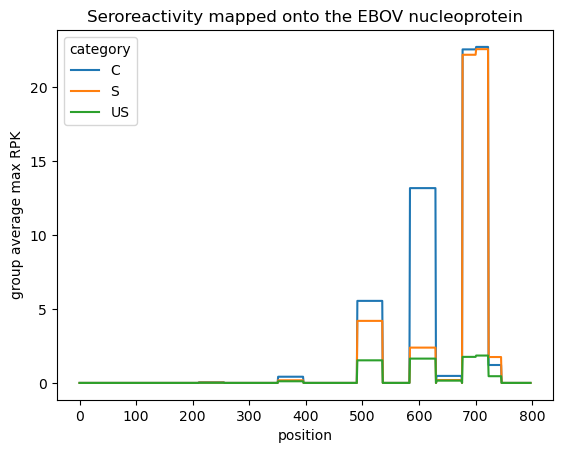

In [87]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

x = np.arange(len(ebov_zaire_np_refseq))

sns.lineplot(data=df_long, x='position', y='RPK', hue='category')

plt.title('Seroreactivity mapped onto the EBOV nucleoprotein')
plt.ylabel('group average max RPK')
plt.show()

## now map onto the glycoprotein

In [89]:
#for the nucleoprotein

# NP_066246.1 spike glycoprotein [Zaire ebolavirus]
ebov_zaire_nucleoprotein_refseq = """
>NP_066246.1 spike glycoprotein [Zaire ebolavirus]
MGVTGILQLPRDRFKRTSFFLWVIILFQRTFSIPLGVIHNSTLQVSDVDKLVCRDKLSSTNQLRSVGLNL
EGNGVATDVPSATKRWGFRSGVPPKVVNYEAGEWAENCYNLEIKKPDGSECLPAAPDGIRGFPRCRYVHK
VSGTGPCAGDFAFHKEGAFFLYDRLASTVIYRGTTFAEGVVAFLILPQAKKDFFSSHPLREPVNATEDPS
SGYYSTTIRYQATGFGTNETEYLFEVDNLTYVQLESRFTPQFLLQLNETIYTSGKRSNTTGKLIWKVNPE
IDTTIGEWAFWETKKNLTRKIRSEELSFTVVSNGAKNISGQSPARTSSDPGTNTTTEDHKIMASENSSAM
VQVHSQGREAAVSHLTTLATISTSPQSLTTKPGPDNSTHNTPVYKLDISEATQVEQHHRRTDNDSTASDT
PSATTAAGPPKAENTNTSKSTDFLDPATTTSPQNHSETAGNNNTHHQDTGEESASSGKLGLITNTIAGVA
GLITGGRRTRREAIVNAQPKCNPNLHYWTTQDEGAAIGLAWIPYFGPAAEGIYIEGLMHNQDGLICGLRQ
LANETTQALQLFLRATTELRTFSILNRKAIDFLLQRWGGTCHILGPDCCIEPHDWTKNITDKIDQIIHDF
VDKTLPDQGDNDNWWTGWRQWIPAGIGVTGVIIAVIALFCICKFVF

"""

#- reference sequence
#this builds one clean amino-acid reference sequence string called ref_seq
ebov_zaire_np_refseq  = "".join( #concatenates all remaining sequence lines into one continuous string
    line.strip() #removes whitespace from each kept line
    for line in ebov_zaire_nucleoprotein_refseq .splitlines() #splits the input text into lines
    if line and not line.startswith(">") #skips empty lines and FASTA header
)

In [90]:
exposed_rpk_long_ebov_np = exposed_rpk_long_ebov[exposed_rpk_long_ebov['protein_name'].isin(glycoprotein_valid)]


df_S = df_SL.filter(regex='^S-')
df_C = df_SL.filter(regex='^C-')


exposed_rpk_long_ebov_np['category'] = "US"
exposed_rpk_long_ebov_np.loc[exposed_rpk_long_ebov_np['sample_id'].isin(df_S.columns), "category"] = 'S'
exposed_rpk_long_ebov_np.loc[exposed_rpk_long_ebov_np['sample_id'].isin(df_C.columns), "category"] = 'C'

mean_rpk_per_cat = ( 
    exposed_rpk_long_ebov_np.reset_index()
    .groupby(["peptide", "category"], as_index=False)["RPK"]
    .median()
    .rename(columns={"RPK" : "mean_rpk"})
)


/tmp/ipykernel_1784003/397962240.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exposed_rpk_long_ebov_np['category'] = "US"


In [91]:
#.apply() means take every value in this Series and run a function on it
mapped = (
    exposed_rpk_long_ebov_np["sequence"]
    #use pd.Series(..) so pandas expands the dictionary into columns
    .apply(lambda x: pd.Series(map_peptide(x, ebov_zaire_nucleoprotein_refseq)))
    #.apply() automatically returns a DataFrame
)

In [92]:
import numpy as np

#merge mapped/alignment values start and end positions
exposed_rpk_long_lasv_gp_w_mapping = pd.merge(exposed_rpk_long_ebov_np, mapped[['start', 'end', 'method', 'score']], on = 'peptide', how='left')

protein_length = len(ebov_zaire_nucleoprotein_refseq)

profiles = {}

for sample, group in exposed_rpk_long_lasv_gp_w_mapping.groupby('sample_id', sort=False):
    #splits the dataframe into each sample_id and all rows belonging to that sample_id are a group

    profile = np.zeros(protein_length) #initialize every residue as 0

    for start, end, value in group[['start', 'end', 'RPK']].itertuples(index=False, name=None):
        if pd.isna(value):
            continue

        start = int(start)
        end = int(end)

        profile[start:end] = np.maximum(profile[start:end], float(value))

    profiles[sample] = profile

In [93]:
profiles_df = pd.DataFrame.from_dict(profiles, orient="index") #this interprets keys as row labels. now the #cols = protein length
#profiles_df.columns = range(1, protein_length + 1) #converting to 1-based indexing
profiles_df.index.name='sample_id'
profiles_df.reset_index()

#mapping to group 

sample_category = (
    exposed_rpk_long_ebov_np[["sample_id", "category"]]
    .drop_duplicates()
)

profiles_df = profiles_df.merge(sample_category, on="sample_id")

group_mean = (
    profiles_df.groupby("category").mean(numeric_only=True)
)

## reshape to long df with columns category, position, and value to use seaborn plotting

df_long = group_mean.reset_index().melt(
    id_vars='category', #identifier variables (keep category column as is
    var_name='position', #new column with old column names
    value_name='RPK' #new column with numeric values
)



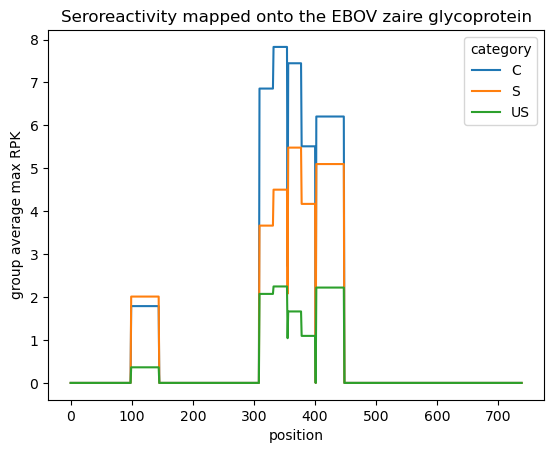

In [95]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

x = np.arange(len(ebov_zaire_np_refseq))

sns.lineplot(data=df_long, x='position', y='RPK', hue='category')

plt.title('Seroreactivity mapped onto the EBOV zaire glycoprotein')
plt.ylabel('group average max RPK')
plt.show()